<a href="https://colab.research.google.com/github/fcoliveira-utfpr/aquacrop_ml/blob/main/12_analise_milho_economica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Configuração e carregamento dos dados

In [1]:
!pip install -q geobr unidecode

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import geobr
import unidecode
import matplotlib.ticker as mticker

BASE_URL = "https://raw.githubusercontent.com/fcoliveira-utfpr/aquacrop_ml/main/"

def carregar(nome_arquivo, **kwargs):
    """Lê um CSV diretamente do GitHub (raw) para um DataFrame pandas."""
    return pd.read_csv(BASE_URL + nome_arquivo, **kwargs)

  error: subprocess-exited-with-error
  
  × pip subprocess to install build dependencies did not run successfully.
  │ exit code: 1
  ╰─> [491 lines of output]
        Using cached scikit_build_core-1.0.3-py3-none-any.whl.metadata (19 kB)
        Using cached cython-3.2.9-cp39-abi3-macosx_10_9_x86_64.whl.metadata (4.6 kB)
        Using cached libcst-1.9.0.tar.gz (914 kB)
        Installing build dependencies: started
        Installing build dependencies: finished with status 'done'
        Getting requirements to build wheel: started
        Getting requirements to build wheel: finished with status 'done'
        Preparing metadata (pyproject.toml): started
        Preparing metadata (pyproject.toml): finished with status 'done'
        Using cached numpy-2.4.6-cp311-cp311-macosx_10_9_x86_64.whl.metadata (6.6 kB)
        Using cached setuptools_scm-10.2.1-py3-none-any.whl.metadata (6.7 kB)
        Using cached packaging-26.3-py3-none-any.whl.metadata (3.5 kB)
        Using cached pat

/Users/coted-sh/Python/VS_CODE1/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# Carregamento de todos os resultados relevantes gerados pelos notebooks 05, 09 e 10 do repositório.

# Desempenho do modelo Extra Trees na predição de produtividade (Notebook 05)
resultados_inferencia = carregar("resultados_inferencia.csv")

# Produtividade prevista por município, ano-safra e data de semeadura (Notebook 05/09)
previsoes = carregar("previsoes_oeste_pr.csv")

# Risco climático (ISNA) por combinação município x data de semeadura (Notebook 09, Seção 3.4.1)
risco_clima = carregar("risco_climatico_oeste_pr.csv")

# Risco econômico (margem) por combinação (Notebook 09, Seção 3.4.2) — cenário principal: 100%
# do custo fixo atribuído ao milho safrinha. Os outros 2 cenários de rateio (o milho safrinha
# sucede a soja no mesmo ano-agrícola, então parte do custo fixo já é amortizada pela soja) são
# carregados também, para comparação (Notebook 09, Seção 6.1/6.2).
risco_economico = carregar("risco_economico_oeste_pr.csv")
risco_economico_rateio50 = carregar("risco_economico_oeste_pr_rateio50.csv")
risco_economico_rateio_proporcional = carregar("risco_economico_oeste_pr_rateio_proporcional.csv")

# Matriz integrada com os três eixos + escore ordinal por tercis (Notebook 10, Seção 3.4.3)
matriz_topsis = carregar("matriz_topsis_oeste_pr.csv")

# Recomendação final — abordagem ordinal por tercis (Eq. 7)
melhor_data_ordinal = carregar("melhor_data_semeadura_integrada.csv")

# Recomendação final — abordagem TOPSIS (Eq. 16)
melhor_data_topsis = carregar("melhor_data_semeadura_topsis.csv")

# Padronização do formato da data de semeadura: os valores originais vêm com uma barra
# sobrando no final (ex.: "05/02/"), resquício da exportação. Removemos aqui para leitura correta.
for df in [risco_clima, risco_economico, risco_economico_rateio50, risco_economico_rateio_proporcional,
           matriz_topsis, melhor_data_ordinal, melhor_data_topsis, previsoes]:
    df["data_semeadura"] = df["data_semeadura"].str.rstrip("/")

print("risco_climatico_oeste_pr.csv  :", risco_clima.shape)
print("risco_economico_oeste_pr.csv  :", risco_economico.shape)
print("...rateio 50%                 :", risco_economico_rateio50.shape)
print("...rateio proporcional        :", risco_economico_rateio_proporcional.shape)
print("matriz_topsis_oeste_pr.csv    :", matriz_topsis.shape)
print("melhor_data (ordinal)         :", melhor_data_ordinal.shape)
print("melhor_data (TOPSIS)          :", melhor_data_topsis.shape)
print("previsoes_oeste_pr.csv        :", previsoes.shape)
print("resultados_inferencia.csv     :", resultados_inferencia.shape)
print()
print("Municípios avaliados:", matriz_topsis['municipio'].nunique())
print("Datas de semeadura avaliadas:", sorted(matriz_topsis['data_semeadura'].unique()))

risco_climatico_oeste_pr.csv  : (300, 12)
risco_economico_oeste_pr.csv  : (300, 6)
...rateio 50%                 : (300, 6)
...rateio proporcional        : (300, 6)
matriz_topsis_oeste_pr.csv    : (300, 29)
melhor_data (ordinal)         : (50, 7)
melhor_data (TOPSIS)          : (50, 6)
previsoes_oeste_pr.csv        : (8100, 4)
resultados_inferencia.csv     : (24, 9)

Municípios avaliados: 50
Datas de semeadura avaliadas: ['05/02', '05/03', '15/02', '15/03', '25/02', '25/03']


## 2. Gráfico dos custos e preços deflacionados e real

In [3]:
custoderal = carregar("custo_deral_milho_safrinha.csv")
preco = carregar("precos_milho_pr.csv")

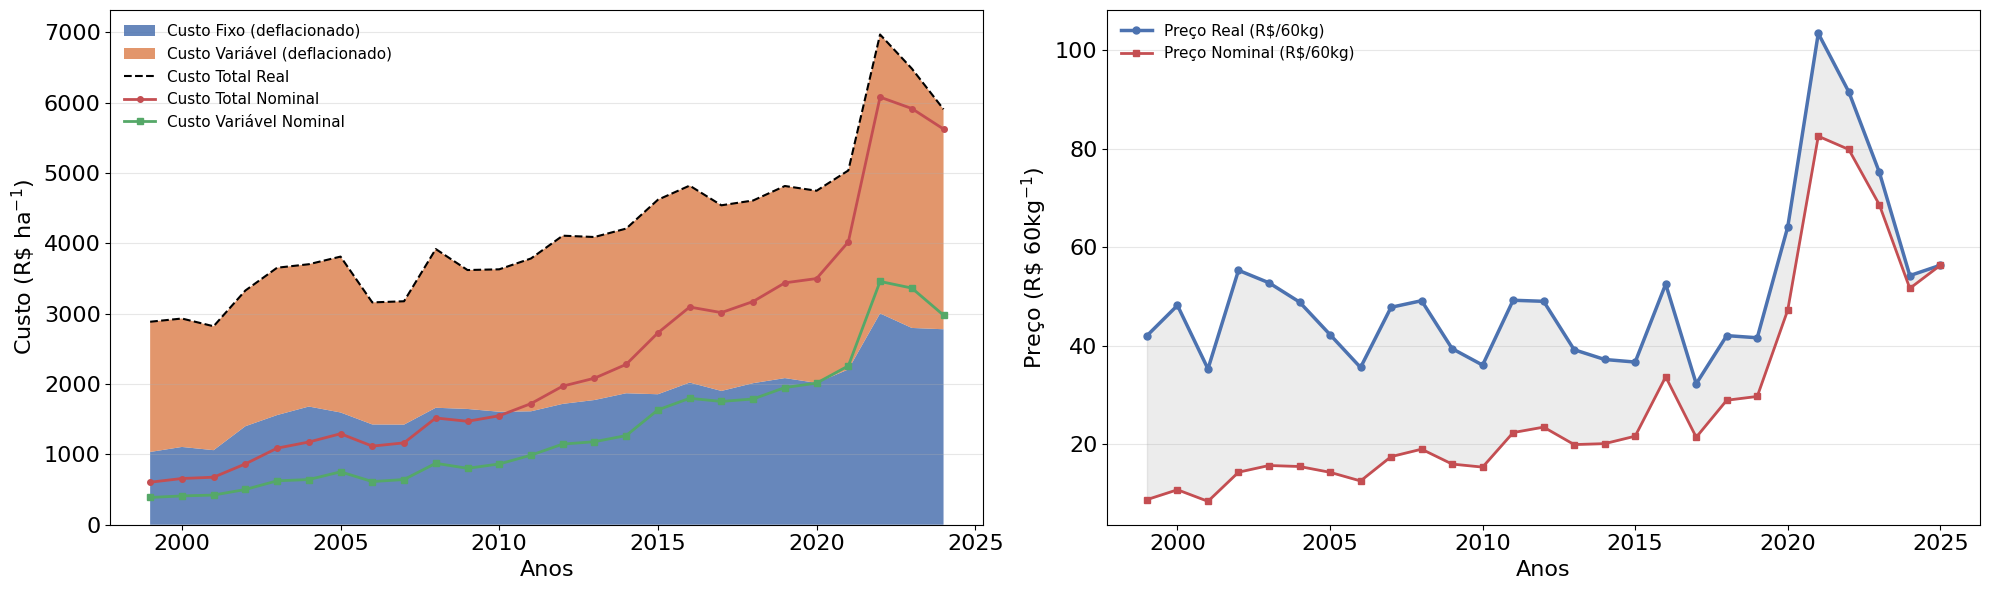

In [4]:

# Ordenar por ano
df_custo = custoderal.sort_values('ano')
df_preco = preco.sort_values('ano')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# ========== PAINEL ESQUERDO: CUSTO ==========
ax1.stackplot(
    df_custo['ano'],
    df_custo['custo_fixo_real'],
    df_custo['custo_rs_ha_variavel_real'],
    labels=['Custo Fixo (deflacionado)', 'Custo Variável (deflacionado)'],
    colors=['#4C72B0', '#DD8452'],
    alpha=0.85
)

ax1.plot(
    df_custo['ano'],
    df_custo['custo_rs_ha_total_real'],
    color='black', linewidth=1.5, linestyle='--',
    label='Custo Total Real'
)

ax1.plot(
    df_custo['ano'],
    df_custo['custo_rs_ha_total_nominal'],
    color='#C44E52', linewidth=2, linestyle='-', marker='o', markersize=4,
    label='Custo Total Nominal'
)

ax1.plot(
    df_custo['ano'],
    df_custo['custo_rs_ha_variavel_nominal'],
    color='#55A868', linewidth=2, linestyle='-', marker='s', markersize=4,
    label='Custo Variável Nominal'
)

ax1.set_xlabel('Anos', fontsize=16)
ax1.set_ylabel(r'Custo (R\$ ha$^{-1}$)', fontsize=16)
ax1.legend(loc='upper left', frameon=False, ncol=1, fontsize=11)
ax1.grid(axis='y', alpha=0.3)
ax1.tick_params(axis='x', labelsize=16)
ax1.tick_params(axis='y', labelsize=16)

# ========== PAINEL DIREITO: PREÇO ==========
ax2.plot(
    df_preco['ano'],
    df_preco['preco_rs_60kg_real'],
    color='#4C72B0', linewidth=2.5, marker='o', markersize=5,
    label='Preço Real (R$/60kg)'
)

ax2.plot(
    df_preco['ano'],
    df_preco['preco_rs_60kg_nominal'],
    color='#C44E52', linewidth=2, linestyle='-', marker='s', markersize=4,
    label='Preço Nominal (R$/60kg)'
)

ax2.fill_between(
    df_preco['ano'],
    df_preco['preco_rs_60kg_real'],
    df_preco['preco_rs_60kg_nominal'],
    color='gray', alpha=0.15
)

ax2.set_xlabel('Anos', fontsize=16)
ax2.set_ylabel(r'Preço (R\$ 60kg$^{-1}$)', fontsize=16)
ax2.legend(loc='upper left', frameon=False, fontsize=11)
ax2.grid(axis='y', alpha=0.3)
ax2.tick_params(axis='x', labelsize=16)
ax2.tick_params(axis='y', labelsize=16)

plt.tight_layout()
plt.show()

## 2. Risco climático

In [5]:
risco_clima

,municipio,data_semeadura,isna_medio,isna_desvio,n_anos,freq_evento_adverso,freq_deficit_faseI,freq_deficit_faseIII,freq_frio_floracao,freq_geada,freq_excesso_faseIV,risco_climatico
0,Anahy,05/02,0.749378,0.116693,27,0.444444,0.148148,0.370370,0.407407,0.000000,0.222222,Inapto (risco > 40%)
1,Anahy,05/03,0.709596,0.111680,27,0.370370,0.222222,0.185185,1.000000,0.000000,0.444444,Risco climático 40%
2,Anahy,15/02,0.735781,0.103092,27,0.296296,0.037037,0.259259,0.740741,0.000000,0.259259,Risco climático 30%
3,Anahy,15/03,0.716376,0.108367,27,0.481481,0.296296,0.259259,1.000000,0.037037,0.518519,Inapto (risco > 40%)
4,Anahy,25/02,0.710012,0.108804,27,0.333333,0.111111,0.259259,0.925926,0.000000,0.370370,Risco climático 40%
...,...,...,...,...,...,...,...,...,...,...,...,...
295,Vera Cruz do Oeste,05/03,0.726441,0.095579,27,0.370370,0.296296,0.148148,1.000000,0.000000,0.518519,Risco climático 40%
296,Vera Cruz do Oeste,15/02,0.727763,0.096866,27,0.296296,0.111111,0.222222,0.851852,0.000000,0.370370,Risco climático 30%
297,Vera Cruz do Oeste,15/03,0.735616,0.098513,27,0.555556,0.444444,0.111111,1.000000,0.037037,0.481481,Inapto (risco > 40%)
298,Vera Cruz do Oeste,25/02,0.719459,0.097998,27,0.296296,0.222222,0.148148,0.962963,0.000000,0.407407,Risco climático 30%


/var/folders/50/s8hjm0h134j6vnljh7hmbhqc0000gn/T/ipykernel_2338/3638421698.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(dados_boxplot, labels=ordem_datas, patch_artist=True)


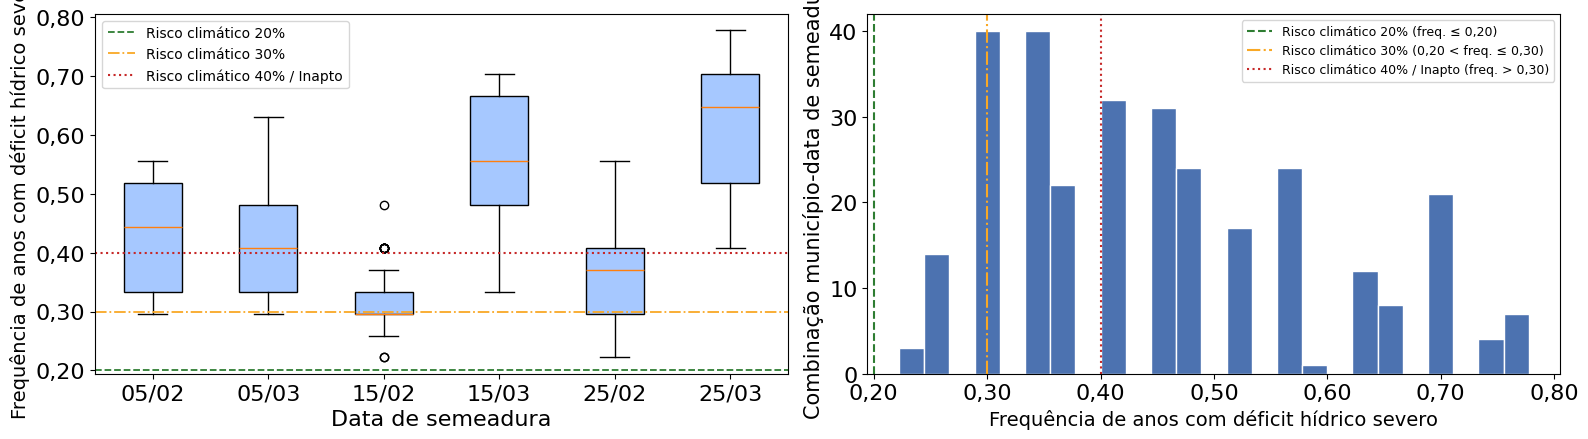

risco_climatico
Inapto (risco > 40%)    181
Risco climático 40%      62
Risco climático 30%      57
Name: count, dtype: int64


In [6]:
def formatar_virgula(x, pos):
    return f"{x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

ordem_datas = sorted(risco_clima["data_semeadura"].unique())

# Limiares oficiais do ZARC (Portaria SPA/MAPA nº 329/2026) sobre a frequência de anos com
# déficit hídrico severo — quanto MAIOR a frequência, PIOR (inverso do ISNA médio antigo).
LIMIAR_20 = 0.20
LIMIAR_30 = 0.30
LIMIAR_40 = 0.40
COR_20 = "#2E7D32"   # verde — fronteira do risco climático 20% (melhor)
COR_30 = "#F9A825"   # âmbar — fronteira do risco climático 30%
COR_40 = "#C62828"   # vermelho — fronteira do risco climático 40% / inapto

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4.5))

# ========== PAINEL ESQUERDO: BOXPLOT ==========
dados_boxplot = [risco_clima.loc[risco_clima["data_semeadura"] == d, "freq_evento_adverso"] for d in ordem_datas]
bp = ax1.boxplot(dados_boxplot, labels=ordem_datas, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("#a6c8ff")

ax1.axhline(LIMIAR_20, color=COR_20, linestyle="--", linewidth=1.3, label="Risco climático 20%")
ax1.axhline(LIMIAR_30, color=COR_30, linestyle="-.", linewidth=1.3, label="Risco climático 30%")
ax1.axhline(LIMIAR_40, color=COR_40, linestyle=":", linewidth=1.5, label="Risco climático 40% / Inapto")
ax1.set_xlabel("Data de semeadura", fontsize=16)
ax1.set_ylabel("Frequência de anos com déficit hídrico severo", fontsize=14)
#ax1.set_title("Frequência de déficit hídrico severo por data de semeadura, entre os 50 municípios do Oeste do Paraná")
ax1.legend()
ax1.tick_params(axis='x', labelsize=16)
ax1.tick_params(axis='y', labelsize=16)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(formatar_virgula))

# ========== PAINEL DIREITO: HISTOGRAMA ==========
ax2.hist(risco_clima["freq_evento_adverso"], bins=25, color="#4C72B0", edgecolor="white")

ax2.axvline(LIMIAR_20, color=COR_20, linestyle="--", label="Risco climático 20% (freq. ≤ 0,20)")
ax2.axvline(LIMIAR_30, color=COR_30, linestyle="-.", label="Risco climático 30% (0,20 < freq. ≤ 0,30)")
ax2.axvline(LIMIAR_40, color=COR_40, linestyle=":", label="Risco climático 40% / Inapto (freq. > 0,30)")

ax2.set_xlabel("Frequência de anos com déficit hídrico severo", fontsize=14)
ax2.set_ylabel("Combinação município-data de semeadura", fontsize=15)
#ax2.set_title("Distribuição da frequência de déficit hídrico severo entre as 300 combinações avaliadas")
ax2.legend(loc='upper right', fontsize=9)
ax2.tick_params(axis='x', labelsize=16)
ax2.tick_params(axis='y', labelsize=16)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(formatar_virgula))

plt.tight_layout()
plt.show()

# Contagem de combinações por classe de risco climático
print(risco_clima["risco_climatico"].value_counts())

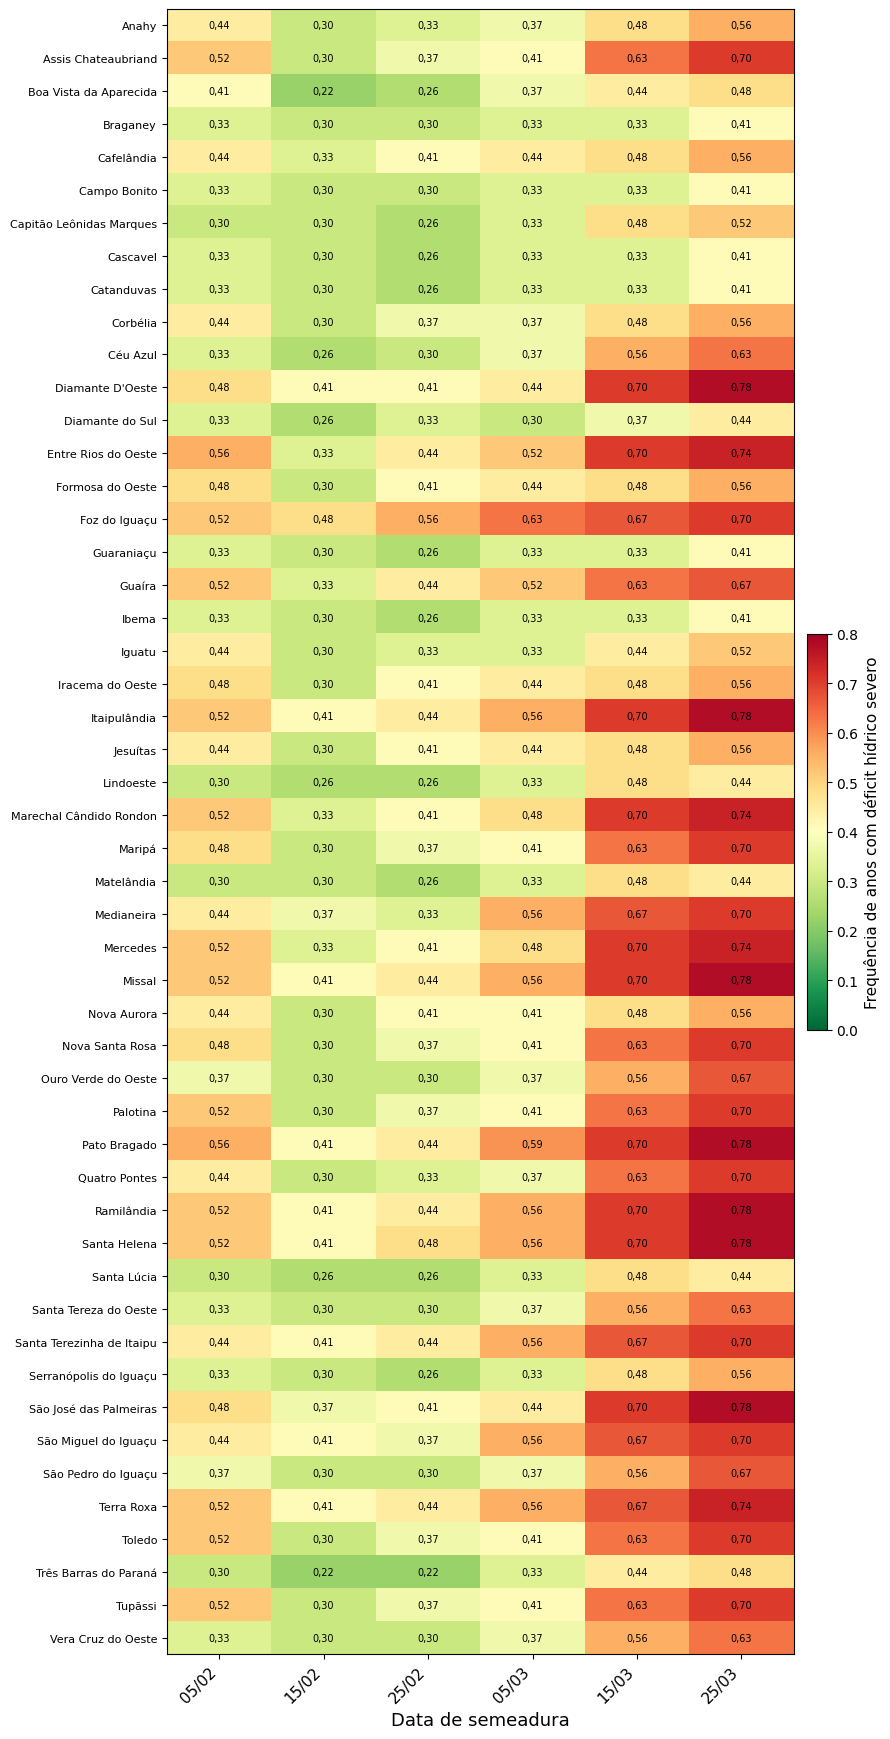

In [7]:
# Ordem cronológica (a ordenação alfabética anterior misturava fevereiro e março por dia)
SEM = ['05/02', '15/02', '25/02', '05/03', '15/03', '25/03']
pivot_risco_clima = risco_clima.pivot(index="municipio", columns="data_semeadura", values="freq_evento_adverso")[SEM]

fig, ax = plt.subplots(figsize=(9, max(6, 0.35 * len(pivot_risco_clima))))
im = ax.imshow(pivot_risco_clima, cmap="RdYlGn_r", vmin=0, vmax=0.8, aspect="auto")

ax.set_xticks(range(len(SEM)))
ax.set_xticklabels(SEM, rotation=45, ha="right", fontsize=11)
ax.set_yticks(range(len(pivot_risco_clima.index)))
ax.set_yticklabels(pivot_risco_clima.index, fontsize=8)

for i in range(pivot_risco_clima.shape[0]):
    for j in range(pivot_risco_clima.shape[1]):
        v = pivot_risco_clima.iloc[i, j]
        if pd.notna(v):
            ax.text(j, i, formatar_virgula(v, None), ha="center", va="center", fontsize=7)

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Frequência de anos com déficit hídrico severo", fontsize=11)

ax.set_xlabel("Data de semeadura", fontsize=13)
#ax.set_title("Frequência de déficit hídrico severo por município × data de semeadura", fontsize=13)
plt.tight_layout()
plt.show()

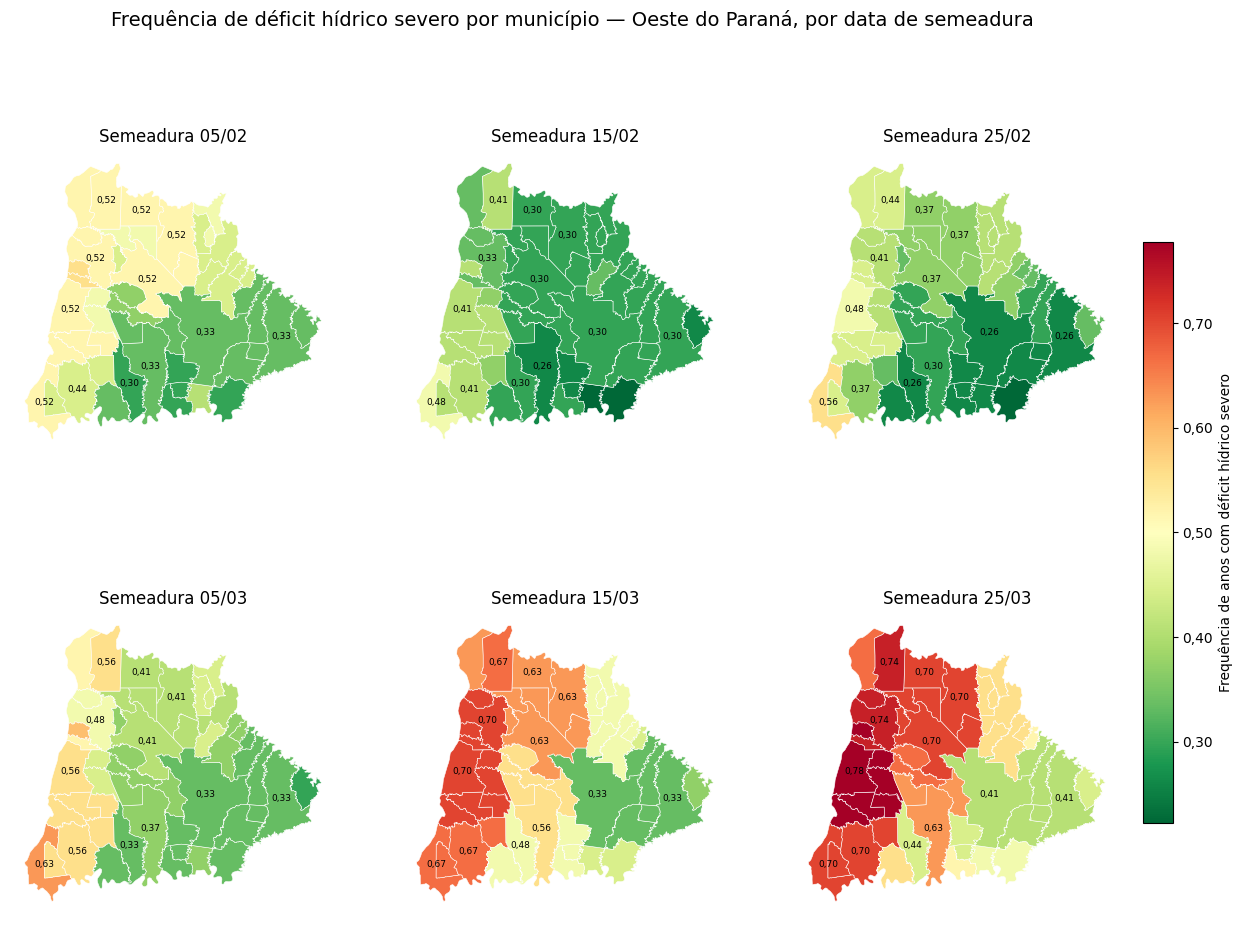

In [8]:
# Multiplot de mapas — frequência de déficit hídrico severo por município, uma para cada
# data de semeadura (usando os polígonos municipais do IBGE via geobr).
muni_pr = geobr.read_municipality(code_muni="PR", year=2020)
muni_pr["nome_norm"] = muni_pr["name_muni"].apply(lambda x: unidecode.unidecode(x).upper())
risco_clima["nome_norm"] = risco_clima["municipio"].apply(lambda x: unidecode.unidecode(x).upper())

oeste_geo = muni_pr[muni_pr["nome_norm"].isin(risco_clima["nome_norm"].unique())].copy()
oeste_geo["area_km2"] = oeste_geo.geometry.to_crs(oeste_geo.estimate_utm_crs()).area / 1e6

# Anota o valor só nos municípios com área grande o suficiente pra caber o texto — em polígonos
# pequenos o número fica ilegível/sobreposto.
N_ANOTAR = 12
municipios_para_anotar = oeste_geo.nlargest(N_ANOTAR, "area_km2")["nome_norm"].tolist()

vmin = risco_clima["freq_evento_adverso"].min()
vmax = risco_clima["freq_evento_adverso"].max()

fig, axes = plt.subplots(2, 3, figsize=(15, 11))
axes = axes.flatten()

for ax, data in zip(axes, SEM):
    dados_data = risco_clima.loc[risco_clima["data_semeadura"] == data, ["nome_norm", "freq_evento_adverso"]]
    gdf = oeste_geo.merge(dados_data, on="nome_norm", how="left")
    gdf.plot(
        column="freq_evento_adverso", cmap="RdYlGn_r", vmin=vmin, vmax=vmax,
        edgecolor="white", linewidth=0.4, ax=ax, missing_kwds={"color": "lightgrey"},
    )
    ax.set_title(f"Semeadura {data}", fontsize=12)
    ax.set_axis_off()

    anotar = gdf[gdf["nome_norm"].isin(municipios_para_anotar)]
    for _, row in anotar.iterrows():
        if pd.isna(row["freq_evento_adverso"]):
            continue
        centroide = row.geometry.centroid
        ax.annotate(
            formatar_virgula(row["freq_evento_adverso"], None),
            xy=(centroide.x, centroide.y), ha="center", va="center",
            fontsize=6.5, color="black",
        )

sm = plt.cm.ScalarMappable(cmap="RdYlGn_r", norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.tolist(), fraction=0.025, pad=0.02, location="right")
cbar.set_label("Frequência de anos com déficit hídrico severo")
cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(formatar_virgula))

fig.suptitle(
    "Frequência de déficit hídrico severo por município — Oeste do Paraná, por data de semeadura",
    y=0.97, fontsize=14,
)
plt.show()

## 3. Risco economico

In [9]:
risco_economico

,municipio,data_semeadura,n_anos,pct_anos_cobre_custo,margem_media_rs_ha,risco_economico
0,Anahy,05/02,26,7.7,-874.341029,Viabilidade intermediária
1,Anahy,05/03,26,7.7,-871.184144,Mais viável
2,Anahy,15/02,26,3.8,-885.637017,Viabilidade intermediária
3,Anahy,15/03,26,3.8,-874.048059,Viabilidade intermediária
4,Anahy,25/02,26,3.8,-874.832799,Viabilidade intermediária
...,...,...,...,...,...,...
295,Vera Cruz do Oeste,05/03,26,7.7,-853.936316,Mais viável
296,Vera Cruz do Oeste,15/02,26,7.7,-890.255744,Viabilidade intermediária
297,Vera Cruz do Oeste,15/03,26,7.7,-871.658598,Mais viável
298,Vera Cruz do Oeste,25/02,26,7.7,-861.987501,Mais viável


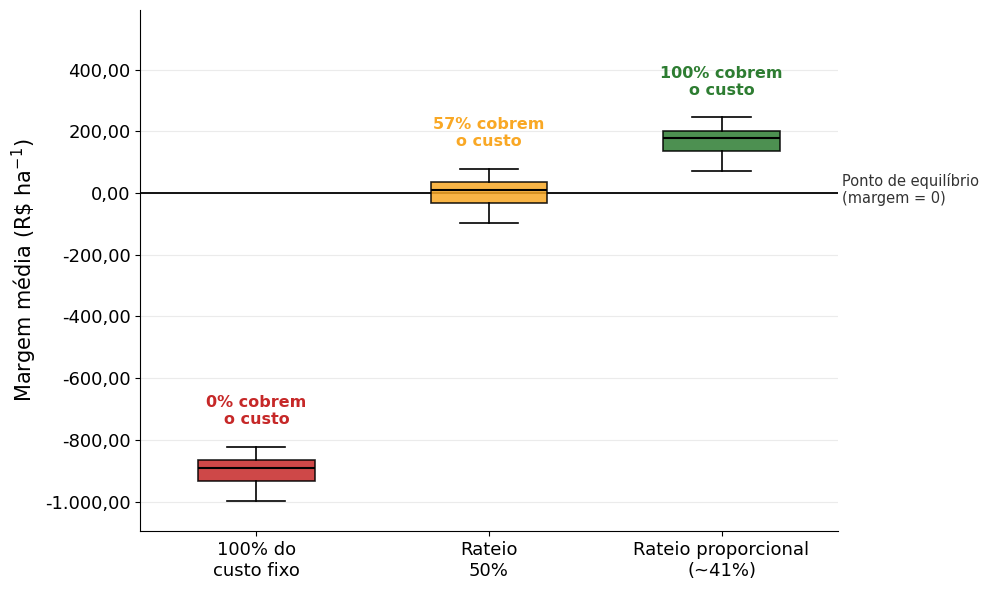

In [10]:
# Gráfico 2 — sensibilidade da margem ao rateio do custo fixo entre soja e milho safrinha
# (o milho safrinha sucede a soja no mesmo ano-agrícola, na mesma área/máquina — o cenário de
# 100% assume que ele arca sozinho com terra/depreciação, como se fosse plantado isolado)
cenarios_rateio = {
    "100% do\ncusto fixo": risco_economico["margem_media_rs_ha"],
    "Rateio\n50%": risco_economico_rateio50["margem_media_rs_ha"],
    "Rateio proporcional\n(~41%)": risco_economico_rateio_proporcional["margem_media_rs_ha"],
}
cores_cenario = ["#C62828", "#F9A825", "#2E7D32"]  # do mais restritivo (vermelho) ao mais permissivo (verde)

fig, ax = plt.subplots(figsize=(10, 6))

bp = ax.boxplot(
    cenarios_rateio.values(), tick_labels=cenarios_rateio.keys(), patch_artist=True,
    widths=0.5, medianprops={"color": "black", "linewidth": 1.5},
    boxprops={"linewidth": 1.2}, whiskerprops={"linewidth": 1.2}, capprops={"linewidth": 1.2},
)
for patch, cor in zip(bp["boxes"], cores_cenario):
    patch.set_facecolor(cor)
    patch.set_alpha(0.85)

ax.axhline(0, color="black", linewidth=1.3, zorder=1)
ax.text(3.52, 12, "Ponto de equilíbrio\n(margem = 0)", fontsize=10.5, va="center", ha="left", color="#333333")

ax.grid(axis="y", alpha=0.25, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

# Headroom fixo no topo (28% do range) pra anotação de % nunca encostar no título.
todos_valores = pd.concat(cenarios_rateio.values())
ymin, ymax = todos_valores.min(), todos_valores.max()
folga = 0.28 * (ymax - ymin)
ax.set_ylim(ymin - 0.08 * (ymax - ymin), ymax + folga)

ax.set_ylabel(r"Margem média (R\$ ha$^{-1}$)", fontsize=15)
#ax.set_title("Margem econômica segundo o rateio do custo fixo entre soja e milho safrinha", fontsize=15, pad=14)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(formatar_virgula))
ax.tick_params(axis="both", labelsize=13)

for i, (serie, cor) in enumerate(zip(cenarios_rateio.values(), cores_cenario), start=1):
    pct_cobre = 100 * (serie >= 0).mean()
    ax.annotate(
        f"{pct_cobre:.0f}% cobrem\no custo",
        xy=(i, serie.max()), xytext=(0, 14), textcoords="offset points",
        ha="center", va="bottom", fontsize=11.5, color=cor, fontweight="bold",
    )

plt.tight_layout()
plt.show()

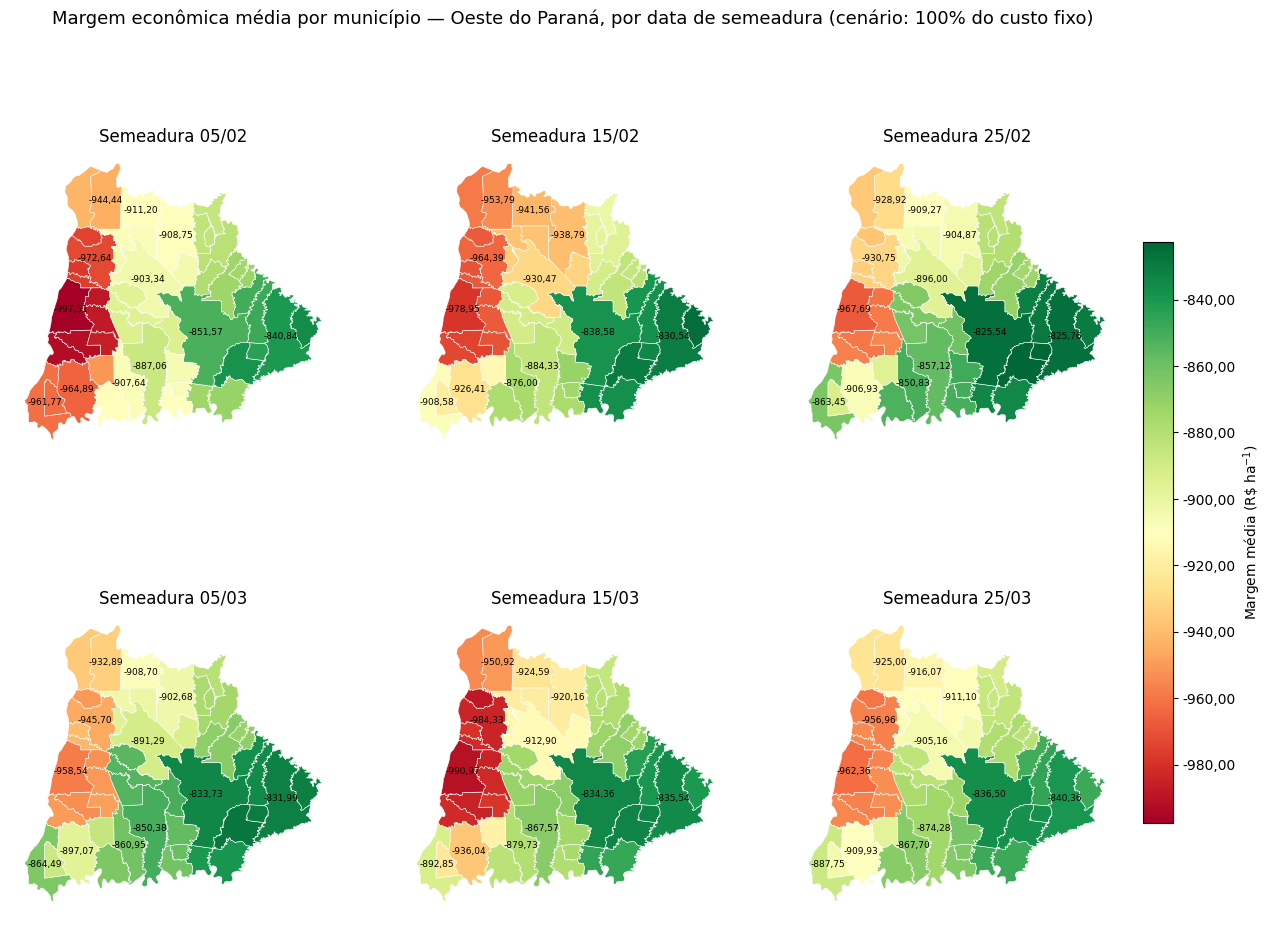

In [11]:
# Gráfico 3 — multiplot de mapas: margem econômica média por município, uma para cada data de
# semeadura (cenário: 100% do custo fixo), usando os mesmos polígonos municipais do geobr.
risco_economico["nome_norm"] = risco_economico["municipio"].apply(lambda x: unidecode.unidecode(x).upper())

vmin_econ = risco_economico["margem_media_rs_ha"].min()
vmax_econ = risco_economico["margem_media_rs_ha"].max()

fig, axes = plt.subplots(2, 3, figsize=(15, 11))
axes = axes.flatten()

for ax, data in zip(axes, SEM):
    dados_data = risco_economico.loc[risco_economico["data_semeadura"] == data, ["nome_norm", "margem_media_rs_ha"]]
    gdf = oeste_geo.merge(dados_data, on="nome_norm", how="left")
    gdf.plot(
        column="margem_media_rs_ha", cmap="RdYlGn", vmin=vmin_econ, vmax=vmax_econ,
        edgecolor="white", linewidth=0.4, ax=ax, missing_kwds={"color": "lightgrey"},
    )
    ax.set_title(f"Semeadura {data}", fontsize=12)
    ax.set_axis_off()

    anotar = gdf[gdf["nome_norm"].isin(municipios_para_anotar)]
    for _, row in anotar.iterrows():
        if pd.isna(row["margem_media_rs_ha"]):
            continue
        centroide = row.geometry.centroid
        ax.annotate(
            formatar_virgula(row["margem_media_rs_ha"], None),
            xy=(centroide.x, centroide.y), ha="center", va="center",
            fontsize=6.5, color="black",
        )

sm = plt.cm.ScalarMappable(cmap="RdYlGn", norm=plt.Normalize(vmin=vmin_econ, vmax=vmax_econ))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.tolist(), fraction=0.025, pad=0.02, location="right")
cbar.set_label(r"Margem média (R\$ ha$^{-1}$)")
cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(formatar_virgula))

fig.suptitle(
    "Margem econômica média por município — Oeste do Paraná, por data de semeadura (cenário: 100% do custo fixo)",
    y=0.97, fontsize=13,
)
plt.show()

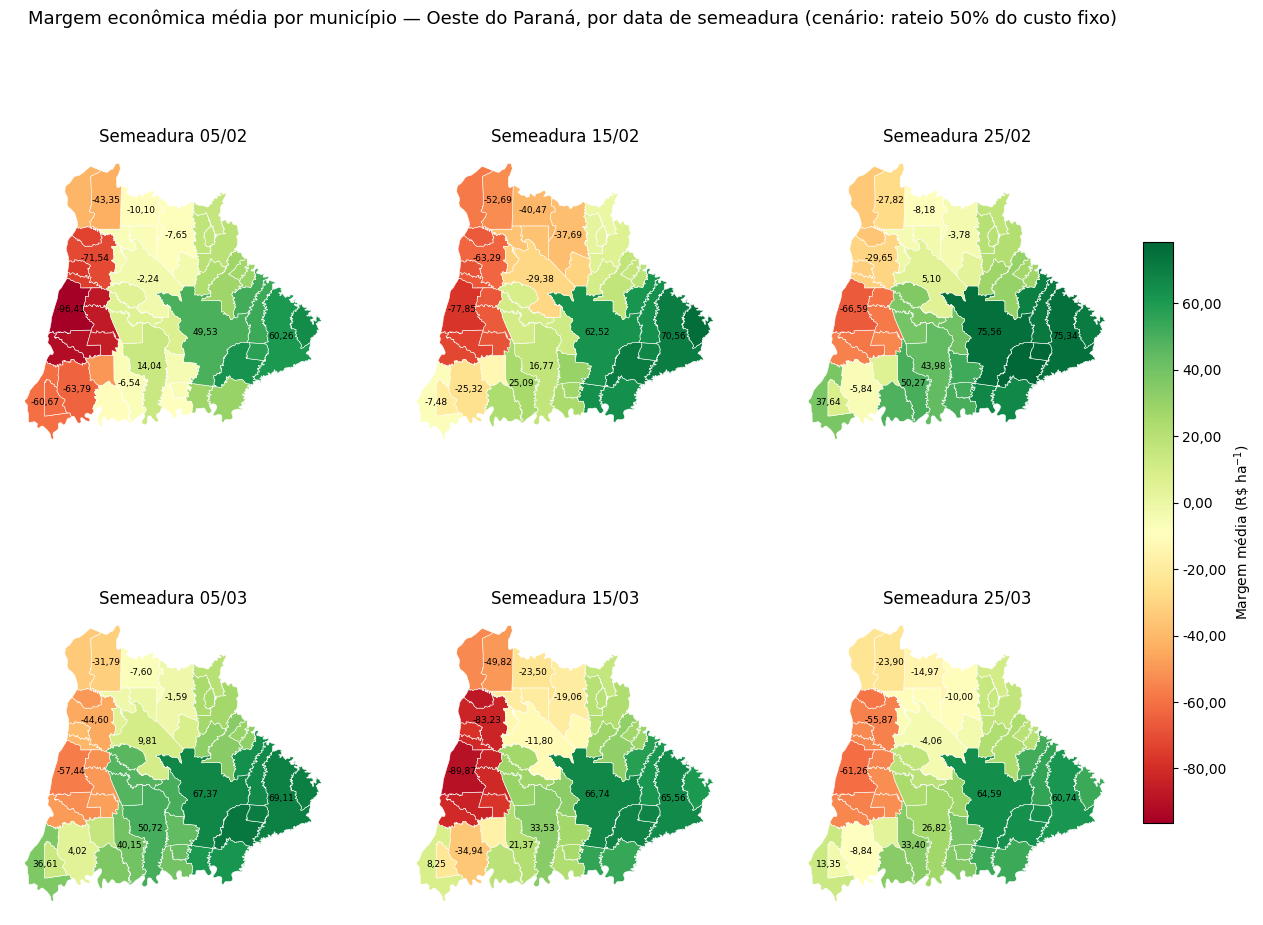

In [12]:
# Gráfico — multiplot de mapas: margem econômica média por município, uma para cada data de
# semeadura (cenário: rateio 50% do custo fixo).
risco_economico_rateio50["nome_norm"] = risco_economico_rateio50["municipio"].apply(lambda x: unidecode.unidecode(x).upper())

vmin_econ = risco_economico_rateio50["margem_media_rs_ha"].min()
vmax_econ = risco_economico_rateio50["margem_media_rs_ha"].max()

fig, axes = plt.subplots(2, 3, figsize=(15, 11))
axes = axes.flatten()

for ax, data in zip(axes, SEM):
    dados_data = risco_economico_rateio50.loc[risco_economico_rateio50["data_semeadura"] == data, ["nome_norm", "margem_media_rs_ha"]]
    gdf = oeste_geo.merge(dados_data, on="nome_norm", how="left")
    gdf.plot(
        column="margem_media_rs_ha", cmap="RdYlGn", vmin=vmin_econ, vmax=vmax_econ,
        edgecolor="white", linewidth=0.4, ax=ax, missing_kwds={"color": "lightgrey"},
    )
    ax.set_title(f"Semeadura {data}", fontsize=12)
    ax.set_axis_off()

    anotar = gdf[gdf["nome_norm"].isin(municipios_para_anotar)]
    for _, row in anotar.iterrows():
        if pd.isna(row["margem_media_rs_ha"]):
            continue
        centroide = row.geometry.centroid
        ax.annotate(
            formatar_virgula(row["margem_media_rs_ha"], None),
            xy=(centroide.x, centroide.y), ha="center", va="center",
            fontsize=6.5, color="black",
        )

sm = plt.cm.ScalarMappable(cmap="RdYlGn", norm=plt.Normalize(vmin=vmin_econ, vmax=vmax_econ))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.tolist(), fraction=0.025, pad=0.02, location="right")
cbar.set_label(r"Margem média (R\$ ha$^{-1}$)")
cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(formatar_virgula))

fig.suptitle(
    "Margem econômica média por município — Oeste do Paraná, por data de semeadura (cenário: rateio 50% do custo fixo)",
    y=0.97, fontsize=13,
)
plt.show()

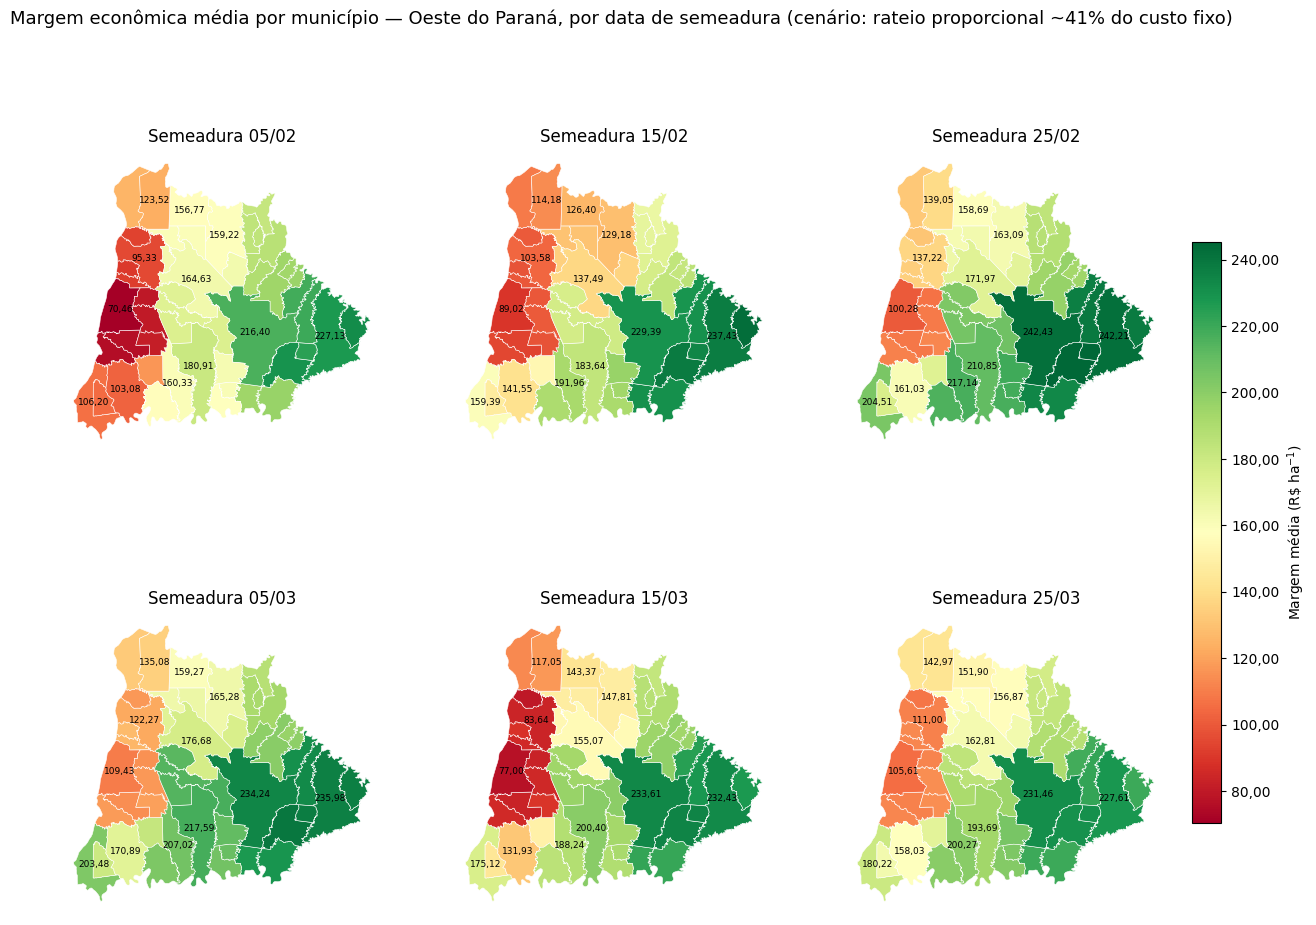

In [13]:
# Gráfico — multiplot de mapas: margem econômica média por município, uma para cada data de
# semeadura (cenário: rateio proporcional (~41%)).
risco_economico_rateio_proporcional["nome_norm"] = risco_economico_rateio_proporcional["municipio"].apply(lambda x: unidecode.unidecode(x).upper())

vmin_econ = risco_economico_rateio_proporcional["margem_media_rs_ha"].min()
vmax_econ = risco_economico_rateio_proporcional["margem_media_rs_ha"].max()

fig, axes = plt.subplots(2, 3, figsize=(15, 11))
axes = axes.flatten()

for ax, data in zip(axes, SEM):
    dados_data = risco_economico_rateio_proporcional.loc[risco_economico_rateio_proporcional["data_semeadura"] == data, ["nome_norm", "margem_media_rs_ha"]]
    gdf = oeste_geo.merge(dados_data, on="nome_norm", how="left")
    gdf.plot(
        column="margem_media_rs_ha", cmap="RdYlGn", vmin=vmin_econ, vmax=vmax_econ,
        edgecolor="white", linewidth=0.4, ax=ax, missing_kwds={"color": "lightgrey"},
    )
    ax.set_title(f"Semeadura {data}", fontsize=12)
    ax.set_axis_off()

    anotar = gdf[gdf["nome_norm"].isin(municipios_para_anotar)]
    for _, row in anotar.iterrows():
        if pd.isna(row["margem_media_rs_ha"]):
            continue
        centroide = row.geometry.centroid
        ax.annotate(
            formatar_virgula(row["margem_media_rs_ha"], None),
            xy=(centroide.x, centroide.y), ha="center", va="center",
            fontsize=6.5, color="black",
        )

sm = plt.cm.ScalarMappable(cmap="RdYlGn", norm=plt.Normalize(vmin=vmin_econ, vmax=vmax_econ))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.tolist(), fraction=0.025, pad=0.02, location="right")
cbar.set_label(r"Margem média (R\$ ha$^{-1}$)")
cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(formatar_virgula))

fig.suptitle(
    "Margem econômica média por município — Oeste do Paraná, por data de semeadura (cenário: rateio proporcional ~41% do custo fixo)",
    y=0.97, fontsize=13,
)
plt.show()

## 4. PCA — componente agroclimático

O PCA (Notebook 10, Seção 3.4.5) reduz o ISNA médio e a produtividade prevista média — fortemente correlacionados (Pearson r≈0,85) — a um único componente agroclimático, evitando ponderar o componente hídrico duas vezes.

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Recalcula o PCA aqui (mesma padronização e mesma correção de sinal do Notebook 10, Seção 3.4.5)
# só para extrair a variância explicada e os pesos (loadings) por componente — o
# componente_agroclimatico em si já vem pronto em matriz_topsis.
X_pca = StandardScaler().fit_transform(matriz_topsis[["isna_medio", "produtividade_media_kg_ha"]].to_numpy())
pca_diag = PCA(n_components=2)
componentes_pca = pca_diag.fit_transform(X_pca)
pc1 = componentes_pca[:, 0]

if np.corrcoef(pc1, matriz_topsis["produtividade_media_kg_ha"])[0, 1] < 0:
    pc1 = -pc1
    pca_diag.components_[0] = -pca_diag.components_[0]

corr_check = np.corrcoef(pc1, matriz_topsis["componente_agroclimatico"])[0, 1]
print(f"Correlação entre PC1 recalculado e componente_agroclimatico (Notebook 10): {corr_check:.4f}")
print(f"Variância explicada — PC1: {pca_diag.explained_variance_ratio_[0]:.1%}, PC2: {pca_diag.explained_variance_ratio_[1]:.1%}")

Correlação entre PC1 recalculado e componente_agroclimatico (Notebook 10): 1.0000
Variância explicada — PC1: 92.5%, PC2: 7.5%


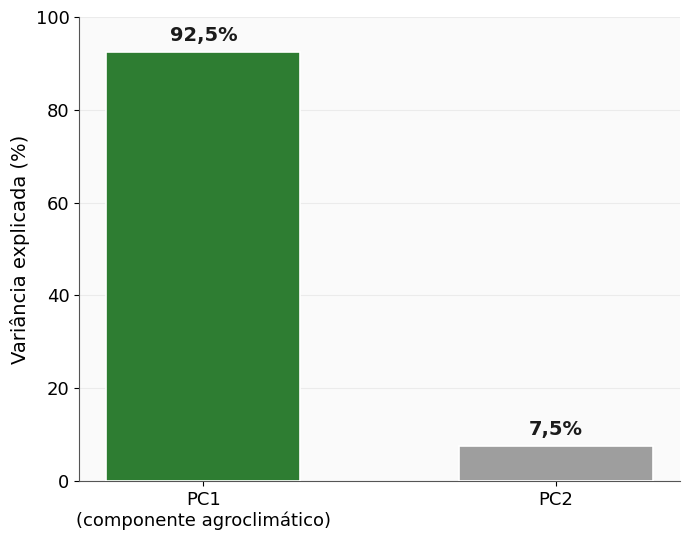

In [15]:
# Gráfico A — variância explicada por componente (scree plot)
variancia_pct = pca_diag.explained_variance_ratio_ * 100
labels_pc = ["PC1\n(componente agroclimático)", "PC2"]
cores_pc = ["#2E7D32", "#9E9E9E"]

def fmt_br(valor, casas=1):
    """Formata número no padrão brasileiro (vírgula decimal)."""
    return f"{valor:.{casas}f}".replace(".", ",")

fig, ax = plt.subplots(figsize=(7, 5.5))
fig.patch.set_facecolor("white")
ax.set_facecolor("#FAFAFA")

barras = ax.bar(
    labels_pc, variancia_pct, color=cores_pc, edgecolor="white",
    linewidth=1.2, width=0.55, zorder=3,
)

for barra, valor in zip(barras, variancia_pct):
    ax.annotate(
        f"{fmt_br(valor)}%",
        xy=(barra.get_x() + barra.get_width() / 2, valor),
        xytext=(0, 8), textcoords="offset points",
        ha="center", fontsize=14, fontweight="bold", color="#1B1B1B",
    )

ax.set_ylabel("Variância explicada (%)", fontsize=14)
#ax.set_title("Variância explicada por componente principal", fontsize=15, pad=16, fontweight="bold")
ax.set_ylim(0, 100)
ax.tick_params(labelsize=13)
ax.grid(axis="y", alpha=0.2, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color("#555555")

plt.tight_layout()
plt.show()

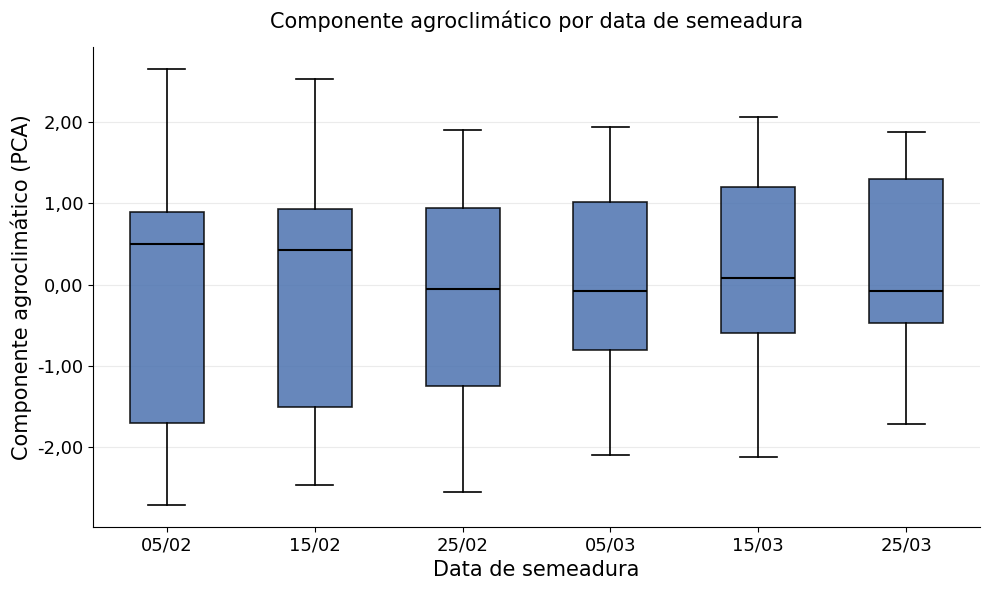

In [16]:
# Gráfico B — componente agroclimático por data de semeadura
dados_boxplot_pca = [matriz_topsis.loc[matriz_topsis["data_semeadura"] == d, "componente_agroclimatico"] for d in SEM]

fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot(
    dados_boxplot_pca, tick_labels=SEM, patch_artist=True, widths=0.5,
    medianprops={"color": "black", "linewidth": 1.5}, boxprops={"linewidth": 1.2},
    whiskerprops={"linewidth": 1.2}, capprops={"linewidth": 1.2},
)
for patch in bp["boxes"]:
    patch.set_facecolor("#4C72B0")
    patch.set_alpha(0.85)

ax.set_ylabel("Componente agroclimático (PCA)", fontsize=15)
ax.set_xlabel("Data de semeadura", fontsize=15)
ax.set_title("Componente agroclimático por data de semeadura", fontsize=15, pad=14)
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.tick_params(labelsize=13)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(formatar_virgula))
plt.tight_layout()
plt.show()

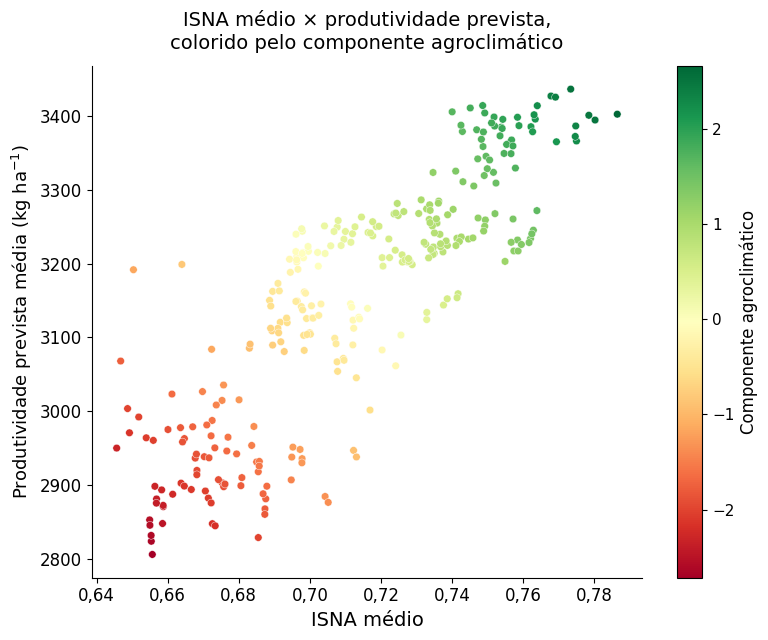

In [17]:
# Gráfico C — ISNA médio × produtividade prevista, colorido pelo componente agroclimático
fig, ax = plt.subplots(figsize=(8, 6.5))
sc = ax.scatter(
    matriz_topsis["isna_medio"], matriz_topsis["produtividade_media_kg_ha"],
    c=matriz_topsis["componente_agroclimatico"], cmap="RdYlGn", s=30, edgecolor="white", linewidth=0.3,
)
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Componente agroclimático", fontsize=12)
cbar.ax.tick_params(labelsize=11)

ax.set_xlabel("ISNA médio", fontsize=14)
ax.set_ylabel("Produtividade prevista média (kg ha$^{-1}$)", fontsize=13)
ax.set_title("ISNA médio × produtividade prevista,\ncolorido pelo componente agroclimático", fontsize=14, pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(formatar_virgula))
ax.tick_params(labelsize=12)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

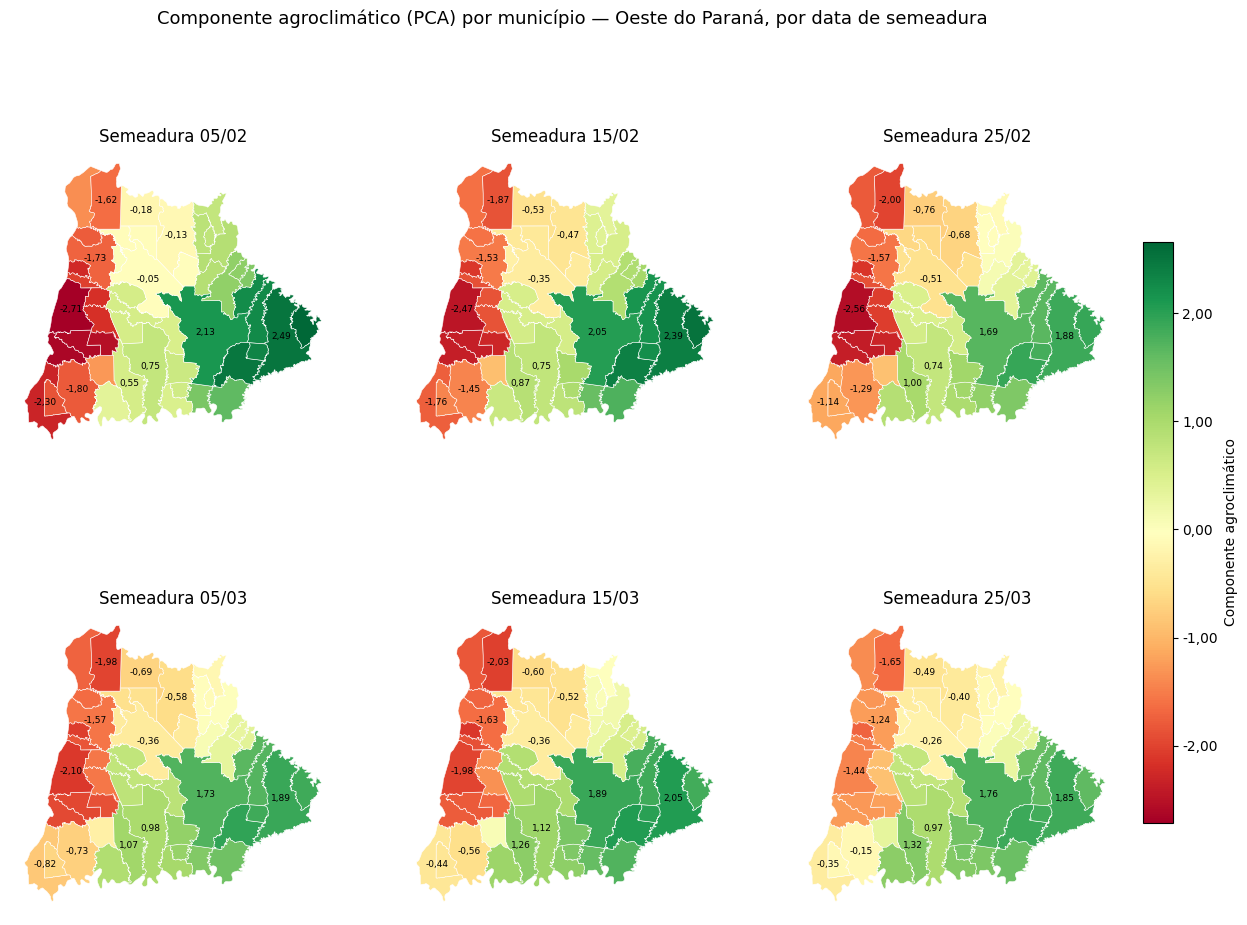

In [18]:
# Gráfico E — multiplot de mapas: componente agroclimático por município, uma para cada data
# de semeadura.
matriz_topsis["nome_norm"] = matriz_topsis["municipio"].apply(lambda x: unidecode.unidecode(x).upper())

vmin_pca = matriz_topsis["componente_agroclimatico"].min()
vmax_pca = matriz_topsis["componente_agroclimatico"].max()

fig, axes = plt.subplots(2, 3, figsize=(15, 11))
axes = axes.flatten()

for ax, data in zip(axes, SEM):
    dados_data = matriz_topsis.loc[matriz_topsis["data_semeadura"] == data, ["nome_norm", "componente_agroclimatico"]]
    gdf = oeste_geo.merge(dados_data, on="nome_norm", how="left")
    gdf.plot(
        column="componente_agroclimatico", cmap="RdYlGn", vmin=vmin_pca, vmax=vmax_pca,
        edgecolor="white", linewidth=0.4, ax=ax, missing_kwds={"color": "lightgrey"},
    )
    ax.set_title(f"Semeadura {data}", fontsize=12)
    ax.set_axis_off()

    anotar = gdf[gdf["nome_norm"].isin(municipios_para_anotar)]
    for _, row in anotar.iterrows():
        if pd.isna(row["componente_agroclimatico"]):
            continue
        centroide = row.geometry.centroid
        ax.annotate(
            formatar_virgula(row["componente_agroclimatico"], None),
            xy=(centroide.x, centroide.y), ha="center", va="center",
            fontsize=6.5, color="black",
        )

sm = plt.cm.ScalarMappable(cmap="RdYlGn", norm=plt.Normalize(vmin=vmin_pca, vmax=vmax_pca))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.tolist(), fraction=0.025, pad=0.02, location="right")
cbar.set_label("Componente agroclimático")
cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(formatar_virgula))

fig.suptitle(
    "Componente agroclimático (PCA) por município — Oeste do Paraná, por data de semeadura",
    y=0.97, fontsize=13,
)
plt.show()

## 5. TOPSIS — resultados multicritério

O TOPSIS (Notebook 10, Seção 3.4.2.3) combina o componente agroclimático (PCA) e a margem econômica em um único score contínuo (0 a 1), calculado para os 3 cenários de rateio do custo fixo entre soja e milho safrinha.

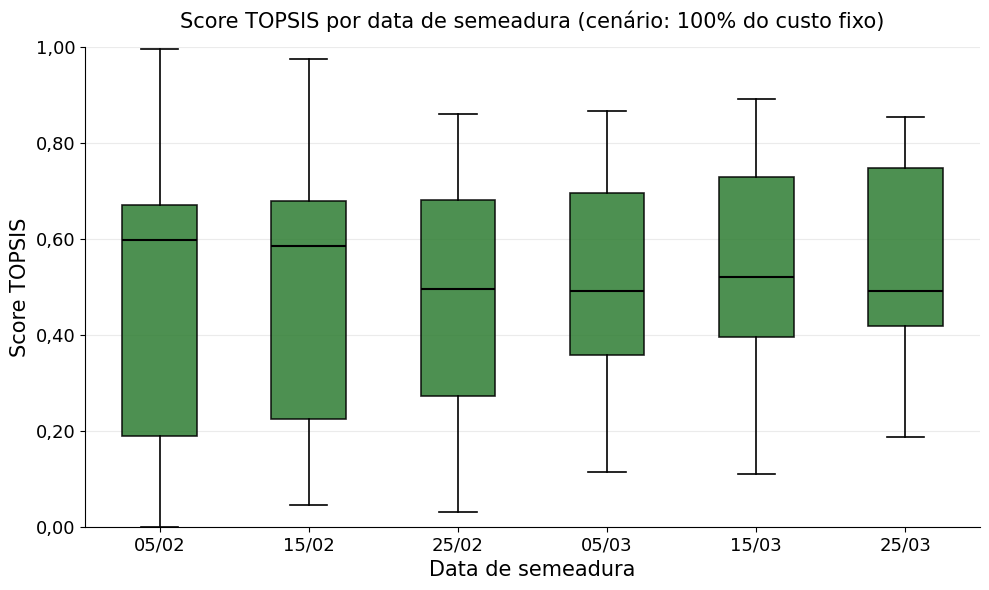

In [19]:
# Boxplot do score TOPSIS por data de semeadura (cenário: 100% do custo fixo)
dados_boxplot_topsis = [matriz_topsis.loc[matriz_topsis["data_semeadura"] == d, "topsis_score"] for d in SEM]

fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot(
    dados_boxplot_topsis, tick_labels=SEM, patch_artist=True, widths=0.5,
    medianprops={"color": "black", "linewidth": 1.5}, boxprops={"linewidth": 1.2},
    whiskerprops={"linewidth": 1.2}, capprops={"linewidth": 1.2},
)
for patch in bp["boxes"]:
    patch.set_facecolor("#2E7D32")
    patch.set_alpha(0.85)

ax.set_ylabel("Score TOPSIS", fontsize=15)
ax.set_xlabel("Data de semeadura", fontsize=15)
ax.set_title("Score TOPSIS por data de semeadura (cenário: 100% do custo fixo)", fontsize=15, pad=14)
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.tick_params(labelsize=13)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(formatar_virgula))
plt.tight_layout()
plt.show()

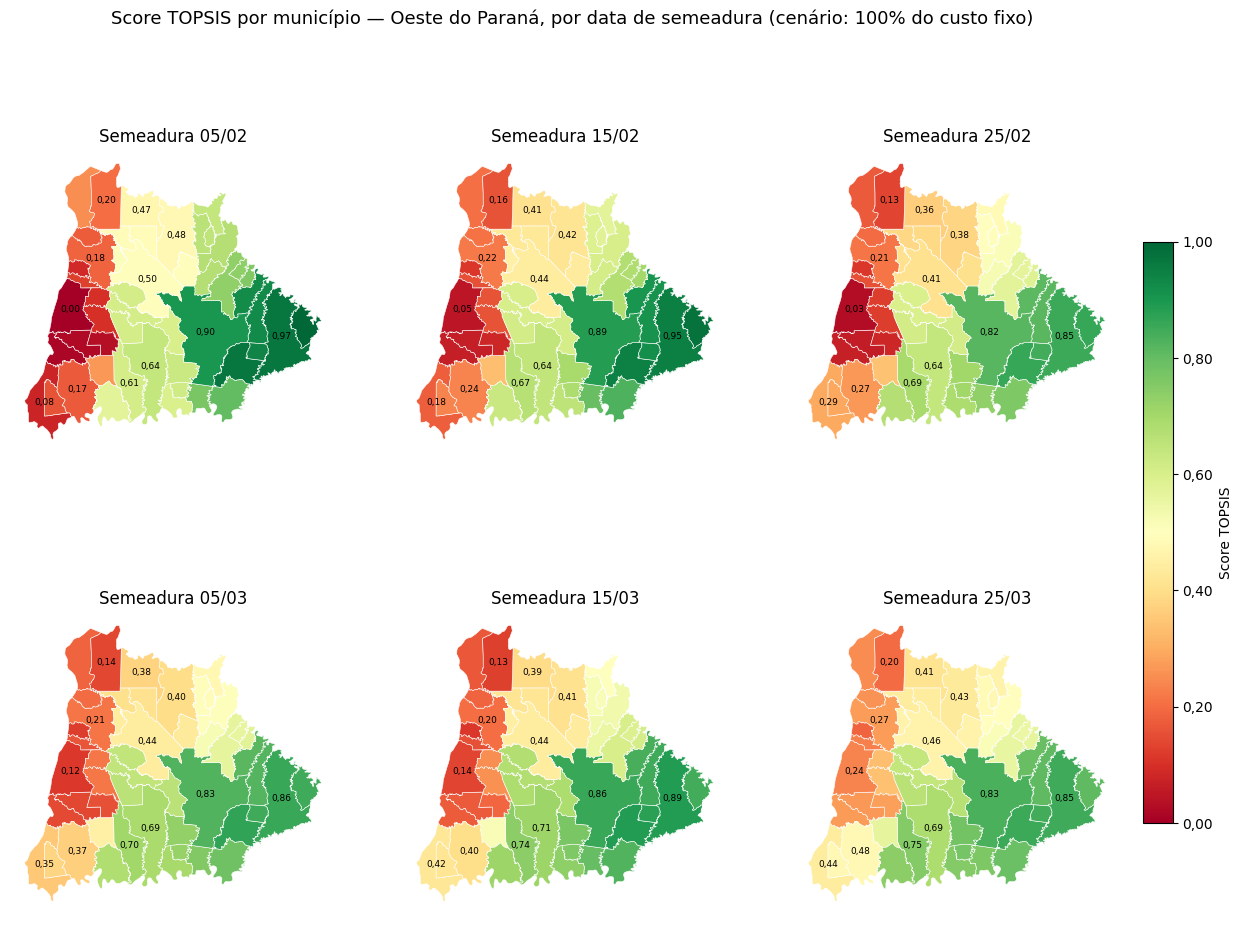

In [20]:
# Multiplot de mapas: score TOPSIS por município, uma para cada data de semeadura
# (cenário: 100% do custo fixo).
vmin_topsis, vmax_topsis = 0, 1

fig, axes = plt.subplots(2, 3, figsize=(15, 11))
axes = axes.flatten()

for ax, data in zip(axes, SEM):
    dados_data = matriz_topsis.loc[matriz_topsis["data_semeadura"] == data, ["nome_norm", "topsis_score"]]
    gdf = oeste_geo.merge(dados_data, on="nome_norm", how="left")
    gdf.plot(
        column="topsis_score", cmap="RdYlGn", vmin=vmin_topsis, vmax=vmax_topsis,
        edgecolor="white", linewidth=0.4, ax=ax, missing_kwds={"color": "lightgrey"},
    )
    ax.set_title(f"Semeadura {data}", fontsize=12)
    ax.set_axis_off()

    anotar = gdf[gdf["nome_norm"].isin(municipios_para_anotar)]
    for _, row in anotar.iterrows():
        if pd.isna(row["topsis_score"]):
            continue
        centroide = row.geometry.centroid
        ax.annotate(
            formatar_virgula(row["topsis_score"], None),
            xy=(centroide.x, centroide.y), ha="center", va="center",
            fontsize=6.5, color="black",
        )

sm = plt.cm.ScalarMappable(cmap="RdYlGn", norm=plt.Normalize(vmin=vmin_topsis, vmax=vmax_topsis))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.tolist(), fraction=0.025, pad=0.02, location="right")
cbar.set_label("Score TOPSIS")
cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(formatar_virgula))

fig.suptitle(
    "Score TOPSIS por município — Oeste do Paraná, por data de semeadura (cenário: 100% do custo fixo)",
    y=0.97, fontsize=13,
)
plt.show()

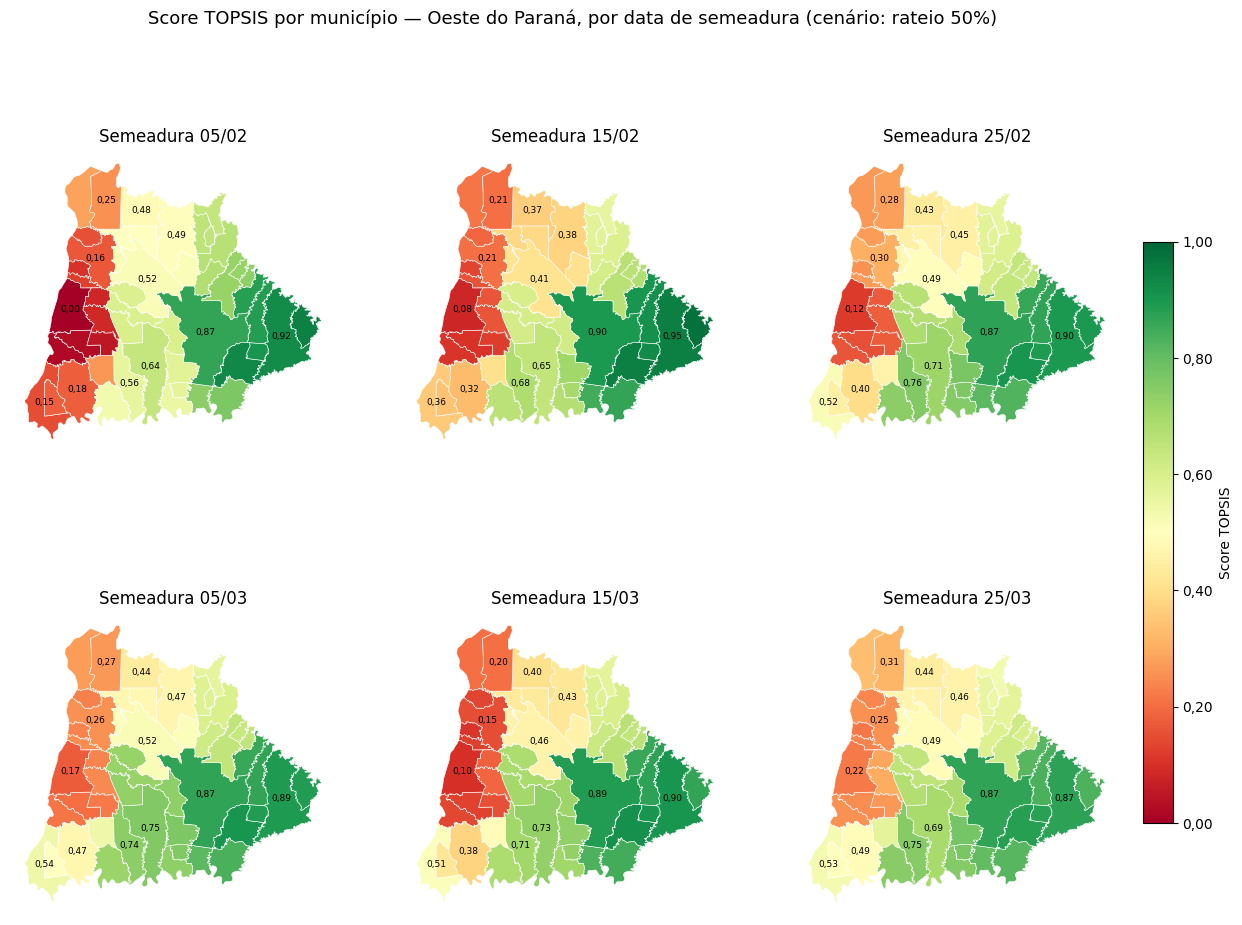

In [21]:
# Multiplot de mapas: score TOPSIS por município, uma para cada data de semeadura
# (cenário: rateio 50%).
vmin_topsis, vmax_topsis = 0, 1

fig, axes = plt.subplots(2, 3, figsize=(15, 11))
axes = axes.flatten()

for ax, data in zip(axes, SEM):
    dados_data = matriz_topsis.loc[matriz_topsis["data_semeadura"] == data, ["nome_norm", "topsis_score_rateio50"]]
    gdf = oeste_geo.merge(dados_data, on="nome_norm", how="left")
    gdf.plot(
        column="topsis_score_rateio50", cmap="RdYlGn", vmin=vmin_topsis, vmax=vmax_topsis,
        edgecolor="white", linewidth=0.4, ax=ax, missing_kwds={"color": "lightgrey"},
    )
    ax.set_title(f"Semeadura {data}", fontsize=12)
    ax.set_axis_off()

    anotar = gdf[gdf["nome_norm"].isin(municipios_para_anotar)]
    for _, row in anotar.iterrows():
        if pd.isna(row["topsis_score_rateio50"]):
            continue
        centroide = row.geometry.centroid
        ax.annotate(
            formatar_virgula(row["topsis_score_rateio50"], None),
            xy=(centroide.x, centroide.y), ha="center", va="center",
            fontsize=6.5, color="black",
        )

sm = plt.cm.ScalarMappable(cmap="RdYlGn", norm=plt.Normalize(vmin=vmin_topsis, vmax=vmax_topsis))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.tolist(), fraction=0.025, pad=0.02, location="right")
cbar.set_label("Score TOPSIS")
cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(formatar_virgula))

fig.suptitle(
    "Score TOPSIS por município — Oeste do Paraná, por data de semeadura (cenário: rateio 50%)",
    y=0.97, fontsize=13,
)
plt.show()

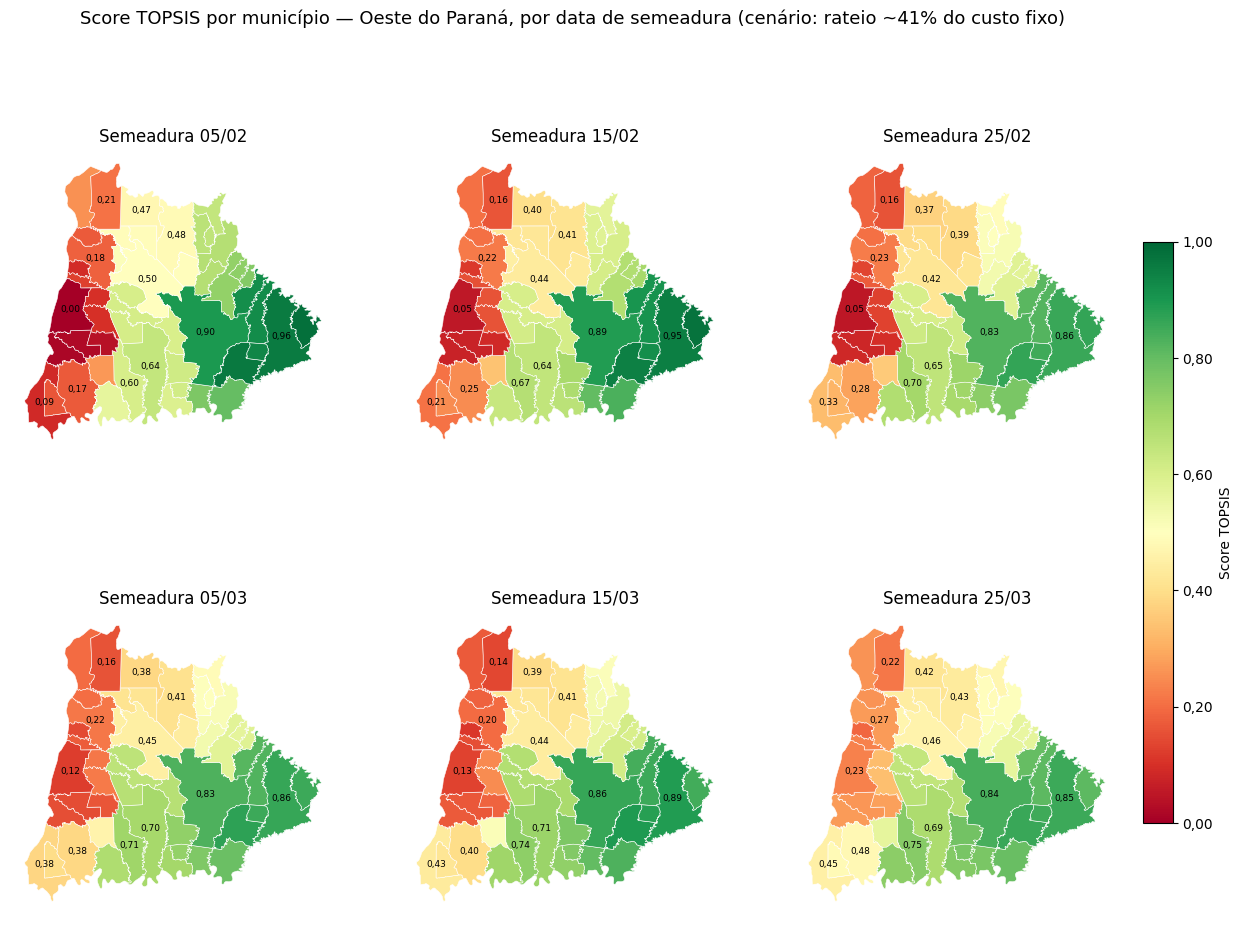

In [32]:
# Multiplot de mapas: score TOPSIS por município, uma para cada data de semeadura
# (cenário: rateio proporcional (~41%)).
vmin_topsis, vmax_topsis = 0, 1

fig, axes = plt.subplots(2, 3, figsize=(15, 11))
axes = axes.flatten()

for ax, data in zip(axes, SEM):
    dados_data = matriz_topsis.loc[matriz_topsis["data_semeadura"] == data, ["nome_norm", "topsis_score_rateio_proporcional"]]
    gdf = oeste_geo.merge(dados_data, on="nome_norm", how="left")
    gdf.plot(
        column="topsis_score_rateio_proporcional", cmap="RdYlGn", vmin=vmin_topsis, vmax=vmax_topsis,
        edgecolor="white", linewidth=0.4, ax=ax, missing_kwds={"color": "lightgrey"},
    )
    ax.set_title(f"Semeadura {data}", fontsize=12)
    ax.set_axis_off()

    anotar = gdf[gdf["nome_norm"].isin(municipios_para_anotar)]
    for _, row in anotar.iterrows():
        if pd.isna(row["topsis_score_rateio_proporcional"]):
            continue
        centroide = row.geometry.centroid
        ax.annotate(
            formatar_virgula(row["topsis_score_rateio_proporcional"], None),
            xy=(centroide.x, centroide.y), ha="center", va="center",
            fontsize=6.5, color="black",
        )

sm = plt.cm.ScalarMappable(cmap="RdYlGn", norm=plt.Normalize(vmin=vmin_topsis, vmax=vmax_topsis))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.tolist(), fraction=0.025, pad=0.02, location="right")
cbar.set_label("Score TOPSIS")
cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(formatar_virgula))

fig.suptitle(
    "Score TOPSIS por município — Oeste do Paraná, por data de semeadura (cenário: rateio ~41% do custo fixo)",
    y=0.97, fontsize=13,
)
plt.show()